In [5]:
import sqlite3, pandas as pd

PAIR_META = {
    "btc100k_dec2026": {"theta": 0.07, "resolves": "2026-12-31"},
    "btc100k_sep2026": {"theta": 0.07, "resolves": "2026-09-30"},
    "eth_sep_3000":    {"theta": 0.07, "resolves": "2026-09-30"},
    "fed_cuts_0":      {"theta": 0.05, "resolves": "2026-12-31"},
    "fed_cuts_1":      {"theta": 0.05, "resolves": "2026-12-31"},
    "fed_cuts_2":      {"theta": 0.05, "resolves": "2026-12-31"},
}

def load_quotes(db="crossvenue.db"):
    c = sqlite3.connect(db)
    q = pd.read_sql("SELECT * FROM quotes", c)
    q["ts"] = pd.to_datetime(q["ts"])
    for col in ["best_bid", "best_ask", "bid_size", "ask_size"]:
        q[col] = pd.to_numeric(q[col], errors="coerce")
    return q

def analyse_pair(q, pair, theta_poly, resolves, tolerance="30s"):
    sel = lambda v, a, b: (q[(q.pair_id == pair) & (q.venue == v)].sort_values("ts")
                           [["ts", "best_bid", "best_ask"]]
                           .rename(columns={"best_bid": a, "best_ask": b}))
    k, p = sel("kalshi", "k_bid", "k_ask"), sel("poly", "p_bid", "p_ask")
    if k.empty or p.empty:
        return pd.DataFrame()

    m = pd.merge_asof(k, p, on="ts", direction="backward",
                      tolerance=pd.Timedelta(tolerance)).dropna(subset=["p_bid", "p_ask"])
    if m.empty:
        return m

    m["pair_id"]  = pair
    m["mid_k"]    = (m.k_bid + m.k_ask) / 2
    m["mid_p"]    = (m.p_bid + m.p_ask) / 2
    m["gap_mid"]  = m.mid_k - m.mid_p
    m["gap_exec"] = pd.concat([m.k_bid - m.p_ask,
                               m.p_bid - m.k_ask], axis=1).max(axis=1).clip(lower=0)

    m["net_exec"] = (m.gap_exec
                     - 0.07       * m.mid_k * (1 - m.mid_k)
                     - theta_poly * m.mid_p * (1 - m.mid_p))

    res = pd.Timestamp(resolves + " 23:59:59", tz=m.ts.dt.tz)
    m["days"] = (res - m.ts).dt.total_seconds() / 86400
    m["ann_return"] = (m.net_exec / (1 - m.gap_exec)) * (365 / m["days"])
    return m

def summarise(m):
    if m.empty:
        return None
    prof = m[m.net_exec > 0]
    return {
        "pair":          m.pair_id.iloc[0],
        "n":             len(m),
        "hours":         round((m.ts.max() - m.ts.min()).total_seconds() / 3600, 1),
        "crossing_%":    round((m.gap_exec > 0).mean() * 100, 2),
        "profitable_%":  round((m.net_exec > 0).mean() * 100, 2),
        "median_ann_%":  round(prof.ann_return.median() * 100, 3) if len(prof) else None,
        "max_ann_%":     round(prof.ann_return.max()    * 100, 3) if len(prof) else None,
    }

q = load_quotes()
results = {p: analyse_pair(q, p, mm["theta"], mm["resolves"]) for p, mm in PAIR_META.items()}
pd.DataFrame([r for r in (summarise(v) for v in results.values()) if r])

,pair,n,hours,crossing_%,profitable_%,median_ann_%,max_ann_%
0,btc100k_dec2026,9105,69.8,30.68,12.70,4.567,11.927
1,btc100k_sep2026,9105,69.8,7.74,7.26,2.177,17.405
2,eth_sep_3000,4979,46.9,19.60,11.35,8.533,117.802
3,fed_cuts_0,4981,46.9,92.61,48.71,0.728,2.137
4,fed_cuts_1,4981,46.9,100.00,100.00,7.616,12.670
5,fed_cuts_2,4981,46.9,55.29,55.29,1.080,3.463


In [2]:
import sqlite3, pandas as pd

c = sqlite3.connect("crossvenue.db")
h = pd.read_sql("SELECT ts, venue, pair_id FROM quotes WHERE pair_id='btc100k_dec2026'", c)
h["ts"] = pd.to_datetime(h["ts"])
h = h.sort_values(["venue", "ts"])
h["gap_min"] = h.groupby("venue")["ts"].diff().dt.total_seconds() / 60

print(h.groupby("venue").agg(n=("ts", "size"), first=("ts", "min"), last=("ts", "max")))
print("\nGaps longer than 5 minutes:")
print(h[h.gap_min > 5][["venue", "ts", "gap_min"]])

           n                     first                      last
venue                                                           
kalshi  9007 2026-09-16 15:00:24+00:00 2026-09-19 12:14:00+00:00
poly    9206 2026-09-16 15:00:24+00:00 2026-09-19 12:14:00+00:00

Gaps longer than 5 minutes:
        venue                        ts  gap_min
10145  kalshi 2026-09-18 13:16:44+00:00  1078.15
10146    poly 2026-09-18 13:16:44+00:00  1078.15


In [3]:
import requests
HEADERS = {"User-Agent": "crossvenue-research/0.1"}

k = requests.get("https://external-api.kalshi.com/trade-api/v2/markets/"
                 "KXRATECUTCOUNT-26DEC31-T1", timeout=15, headers=HEADERS).json()["market"]
print("=== KALSHI ===")
print(k.get("rules_primary", "")[:1500])

ev = requests.get("https://gamma-api.polymarket.com/events?slug=how-many-fed-rate-cuts-in-2026",
                  timeout=15).json()
pm = [m for m in ev[0]["markets"] if "Will 1 Fed rate cut happen" in m["question"]][0]
print("\n=== POLYMARKET ===")
print(pm.get("description", "")[:1500])

=== KALSHI ===
If the Fed cuts 1 times starting Jan 1, 2026 and before 2027, then the market resolves to Yes.

=== POLYMARKET ===
This market will resolve according to the exact amount of cuts of 25 basis points in 2026 by the Fed (including any cuts made during the December meeting).

Emergency rate cuts outside of scheduled FOMC meetings will also count toward the total number of cuts in 2026. This market will remain open until December 31, 2026, 11:59 PM ET, to account for any such emergency actions.

For example, if the Fed cuts rates by 50 bps after a meeting, it would be considered 2 cuts (of 25 bps each).

This market will resolve early to "No" if the specified number of cuts becomes impossible — i.e., if more cuts have already occurred than the strike in question.

Note that cuts between 1–24 bps (inclusive) will also be considered 1 rate cut.

The resolution source for this market will be FOMC statements after meetings scheduled in 2026 according to the official calendar: http

In [4]:
print(k.get("rules_secondary", "")[:2000])

To be clear, 25bp of cuts is equal to one cut (so 25bp cut is 1, 50bp cut is 2, 75bp cut is 3, and so on).


In [6]:
import numpy as np

def with_size(q, pair, theta_poly):
    cols = ["ts", "best_bid", "best_ask", "bid_size", "ask_size"]
    def sel(v, p):
        return (q[(q.pair_id == pair) & (q.venue == v)].sort_values("ts")[cols]
                .rename(columns={"best_bid": p+"bid", "best_ask": p+"ask",
                                 "bid_size": p+"bsz", "ask_size": p+"asz"}))
    m = pd.merge_asof(sel("kalshi", "k_"), sel("poly", "p_"), on="ts",
                      direction="backward", tolerance=pd.Timedelta("30s")).dropna()
    a = m.k_bid - m.p_ask      # sell YES on Kalshi, buy YES on Polymarket
    b = m.p_bid - m.k_ask      # sell YES on Polymarket, buy YES on Kalshi
    m["gap_exec"] = np.maximum(np.maximum(a, b), 0)
    m["size"]     = np.where(a >= b, np.minimum(m.k_bsz, m.p_asz),
                                     np.minimum(m.p_bsz, m.k_asz))
    mk, mp = (m.k_bid + m.k_ask) / 2, (m.p_bid + m.p_ask) / 2
    m["net_exec"] = m.gap_exec - 0.07*mk*(1-mk) - theta_poly*mp*(1-mp)
    m["profit_$"] = m.net_exec.clip(lower=0) * m["size"]
    return m

rows = []
for p, mm in PAIR_META.items():
    m = with_size(q, p, mm["theta"])
    prof = m[m.net_exec > 0]
    rows.append({"pair": p,
                 "profitable_%":    round(len(prof) / len(m) * 100, 1),
                 "median_size":     round(prof["size"].median()) if len(prof) else 0,
                 "median_profit_$": round(prof["profit_$"].median(), 2) if len(prof) else 0,
                 "max_profit_$":    round(prof["profit_$"].max(), 2) if len(prof) else 0})
pd.DataFrame(rows)

,pair,profitable_%,median_size,median_profit_$,max_profit_$
0,btc100k_dec2026,12.7,43,0.19,1.68
1,btc100k_sep2026,7.3,6,0.01,0.36
2,eth_sep_3000,11.3,6,0.02,10.18
3,fed_cuts_0,48.7,146,0.06,2.78
4,fed_cuts_1,100.0,21,0.48,9.34
5,fed_cuts_2,55.3,20,0.05,52.21


In [7]:
import requests
HEADERS = {"User-Agent": "crossvenue-research/0.1"}
KAL = "https://external-api.kalshi.com/trade-api/v2/markets/"

def kalshi_rules(ticker):
    m = requests.get(KAL + ticker, timeout=15, headers=HEADERS).json()["market"]
    return m.get("rules_primary", ""), m.get("rules_secondary", "")

def poly_rules(slug, text):
    ev = requests.get(f"https://gamma-api.polymarket.com/events?slug={slug}", timeout=15).json()
    m = [x for x in ev[0]["markets"] if text in x["question"]][0]
    return m["question"], m.get("description", "")

checks = [
    ("btc100k_dec2026", "KXBTCMAX100-26-DEC", "when-will-bitcoin-hit-100k", "December 31, 2026"),
    ("btc100k_sep2026", "KXBTCMAX100-26-SEP", "when-will-bitcoin-hit-100k", "September 30, 2026"),
    ("eth_sep_3000", "KXETHMAXMON-ETH-26SEP30-300000",
     "what-price-will-ethereum-hit-in-september-2026", "reach $3,000"),
]

for pid, kt, slug, text in checks:
    kp, ks = kalshi_rules(kt)
    pq, pdesc = poly_rules(slug, text)
    print("=" * 90, "\n", pid)
    print("\n--- KALSHI primary ---\n", kp[:1200])
    print("\n--- KALSHI secondary ---\n", ks[:1500])
    print(f"\n--- POLYMARKET: {pq} ---\n", pdesc[:1800])

 btc100k_dec2026

--- KALSHI primary ---
 If the Bitcoin spot price according to the CF Bitcoin Real-Time Index is above $100000.00 starting 02/17/2026 04:00 PM and before Jan 1, 2027 at 12:00AM ET, then the market resolves to Yes.

--- KALSHI secondary ---
 The market resolves based on the CF Bitcoin Real-Time Index (BRTI) using a trimmed mean calculation. The resolution value is calculated by taking all BRTI values for each minute from market issuance until the specified time on the target date, removing the top 20% and bottom 20% of values, then averaging the remaining 60% of values. If the BRTI crosses the threshold at any point during the measurement period (triggering early expiration), the market immediately resolves. If no data is available at the expiration time, the market resolves to No. The market can resolve early if Bitcoin definitively crosses the threshold before the target date and time.

--- POLYMARKET: Will Bitcoin hit $100k by December 31, 2026? ---
 This market wil

In [8]:
rows = []
for p, m in results.items():
    prof = m[m.net_exec > 0]
    a = prof.k_bid - prof.p_ask   # > 0: sell YES on Kalshi, buy YES on Polymarket
    b = prof.p_bid - prof.k_ask   # > 0: sell YES on Polymarket, buy YES on Kalshi
    n = max(len(prof), 1)
    rows.append({"pair": p,
                 "profitable_rows": len(prof),
                 "sell_kalshi_%": round((a > 0).sum() / n * 100, 1),
                 "sell_poly_%":   round((b > 0).sum() / n * 100, 1)})
pd.DataFrame(rows)

,pair,profitable_rows,sell_kalshi_%,sell_poly_%
0,btc100k_dec2026,1156,81.8,18.2
1,btc100k_sep2026,661,56.1,43.9
2,eth_sep_3000,565,2.5,97.5
3,fed_cuts_0,2426,5.8,94.2
4,fed_cuts_1,4981,100.0,0.0
5,fed_cuts_2,2754,100.0,0.0


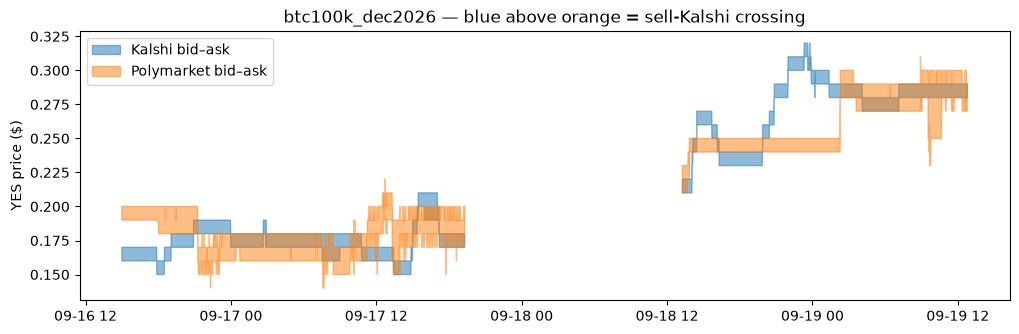

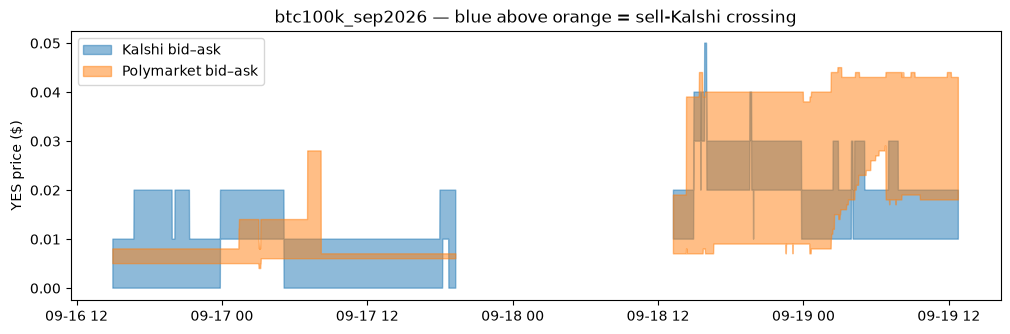

In [9]:
import matplotlib.pyplot as plt

def plot_bands(pair):
    r = (results[pair].set_index("ts")[["k_bid", "k_ask", "p_bid", "p_ask"]]
         .resample("1min").last())          # empty minutes (the outage) become gaps
    r.index = r.index.tz_convert(None)      # plain UTC times for the x-axis
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.fill_between(r.index, r.k_bid, r.k_ask, color="tab:blue",   alpha=0.5, label="Kalshi bid–ask")
    ax.fill_between(r.index, r.p_bid, r.p_ask, color="tab:orange", alpha=0.5, label="Polymarket bid–ask")
    ax.set_title(pair + " — blue above orange = sell-Kalshi crossing")
    ax.set_ylabel("YES price ($)")
    ax.legend(loc="upper left")
    plt.show()

for p in ["btc100k_dec2026", "btc100k_sep2026"]:
    plot_bands(p)

In [10]:
d = q.sort_values(["pair_id", "venue", "ts"]).copy()
state = (d.best_bid.astype(str) + "|" + d.best_ask.astype(str) + "|"
         + d.bid_size.astype(str) + "|" + d.ask_size.astype(str))
d["new_run"] = ((state != state.shift())
                | (d.pair_id != d.pair_id.shift())
                | (d.venue != d.venue.shift())
                | (d.ts.diff() > pd.Timedelta("60s")))      # a collection gap also ends a run
d["run_id"] = d.new_run.cumsum()

runs = d.groupby(["pair_id", "venue", "run_id"]).ts.agg(start="min", end="max").reset_index()
runs["hours"] = ((runs.end - runs.start).dt.total_seconds() / 3600).round(2)

# longest stretch each book went completely unchanged (price AND size), per pair and venue
runs.loc[runs.groupby(["pair_id", "venue"]).hours.idxmax(), ["pair_id", "venue", "start", "end", "hours"]]

,pair_id,venue,start,end,hours
250,btc100k_dec2026,kalshi,2026-09-17 05:06:17+00:00,2026-09-17 06:59:57+00:00,1.89
1555,btc100k_dec2026,poly,2026-09-17 02:52:57+00:00,2026-09-17 04:15:57+00:00,1.38
2750,btc100k_sep2026,kalshi,2026-09-17 05:12:37+00:00,2026-09-17 10:23:38+00:00,5.18
2990,btc100k_sep2026,poly,2026-09-17 08:12:58+00:00,2026-09-17 19:18:35+00:00,11.09
3576,elcrma_ELC,kalshi,2026-09-16 15:00:24+00:00,2026-09-17 13:42:19+00:00,22.70
3866,elcrma_ELC,poly,2026-09-15 20:25:46+00:00,2026-09-15 20:29:06+00:00,0.06
9691,elcrma_RMA,kalshi,2026-09-16 15:00:24+00:00,2026-09-17 13:42:19+00:00,22.70
10018,elcrma_RMA,poly,2026-09-15 20:23:06+00:00,2026-09-15 20:23:26+00:00,0.01
15814,elcrma_TIE,kalshi,2026-09-16 15:00:24+00:00,2026-09-17 13:42:19+00:00,22.70
15826,elcrma_TIE,poly,2026-09-15 18:38:24+00:00,2026-09-15 18:39:24+00:00,0.02
